# UCF101 zero-shot classifier with VideoMAE

_Authors: E. Cabalé, H. Naranjo and R. Paganini_

This notebook extends the original use case notebook at [example_zeroshot.ipynb](example_zeroshot.ipynb) for video. We did so by trying out our video Text-to-Concept to perform zeroshot inference in the UCF101 dataset.

## Imports and Initiation

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torchvision
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

from TextToConcept import TextToConcept
from video_utils import make_dataset, DivideBy255, CTHWToTCHW, ToTensorTuple
from train_video_aligner import SizedLabeledVideoDataset

# Pytorchvideo for video processing and loading
# git clone https://github.com/facebookresearch/pytorchvideo.git
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop, Normalize
from pytorchvideo.data import UniformClipSampler


/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/rodrigopaganini/master/xai/project/Text-to-concept/ViCLIP/viclip_text.py:4: UserWarning: pkg_res

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Using device:", device)

Using device: cpu


## Loading Model

### VideoMAE
In this part, we load VideoMAE model.
In order to use ``TextToConcept`` framework, model should implement these functions/attributes:
+ ``forward_features(x)`` that takes a tensor as the input and outputs the representation (features) of input $x$ when it is passed through the model.
+ ``get_normalizer`` should be the normalizer that the models uses to preprocess the input. e.g., Resnet18, uses standard ImageNet normalizer.
+ Attribute ``has_normalizer`` should be `True` when normalizer is need for the model.

In our work, we achieved this by means of the wrapper `VideoMAETTCTWrapper`.

In [ ]:
from transformers import VideoMAEModel
from video_utils import VideoMAETTCTWrapper

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
videomae_model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
videomae_model = videomae_model.to(device)

model = VideoMAETTCTWrapper(videomae_model, normalizer=torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 9323.49it/s]
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED |  

### Text-to-Concept

<b>Initiating Text-To-Concept Object</b><br>
In this section, we initiate ``TextToConcept`` object which turns the vision encoder (e.g., VideoMAE) into a model capable of integrating language and vision. By doing so, we enable the utilization of certain abilities present in vision-language models.

In [5]:
text_to_concept = TextToConcept(model, 'videomae', 'video')

In this notebook we load a trained Linear Aligner. If you wish to train your own aligner, please run  [train_linear_aligner](train_linear_aligner.py).

This aligner in particular was constructed by aligning VideoMAE features of the Kinetics400 dataset to those of ViCLIP.

In [6]:
path = 'pretrained_aligners/videomae_base_aligner_k400.pth'
text_to_concept.load_linear_aligner(path, device='cpu')

### Zero-shot Classifier

As in the original work, Zero-Shot classification is achieved by encoding classes as prompts (through ViCLIP), the videos as vision features (through aligned TTC), and pick the class with less cosine distance to be the output.

We pick a subset of classes of UCF101 for evaluation.

Preprocessing matches what was used during training ([train_video_aligner.py](train_video_aligner.py)):
- Take clips of 10 s duration (always captures the full duration of the video).
- Samples 16 frames uniformly within the clip, to fit VideoMAE input tensor shape. Note that in a 10 s video, this involves roughly 1 frame every $0.6$ s, which is good enough to capture coarse events in the video for classification. Provided the dataset and datasets classes, this is a reasonable choice: fine-grain events are normally not relevant, and it is good to discard irrelevant sections of the video.
- Resizes and crops by 224 to match VideoMAE input tensor shape, and normalization.

In [7]:
# Dataset path. See download_ucf101.py for instructions on how to download and prepare the dataset.
UCF_ROOT = Path("dataset/ucf101")

# Selected names
ucf_class_names = [
    "PlayingGuitar",
    "BrushingTeeth",
    "Billiards",
    "Archery",
    "HorseRiding",
    "BreastStroke",
]

# Template prompts for zero-shot classification. The {} will be replaced by the class name.
ucf_prompts = ["a video of someone {}", "someone is {}", "a person is {}"]

# ---------------------------------------------------
clip_sampler = UniformClipSampler(clip_duration=10.0)
preprocessing_with_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
            Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

def label_as_prompt(label):
    return ''.join([c if not c.isupper() else ' ' + c.lower() for c in label])

ucf_text_labels = [label_as_prompt(name) for name in ucf_class_names]
CLASSES_TO_KEEP = set(ucf_class_names)

assert len(ucf_class_names) == len(ucf_text_labels)
assert len(ucf_class_names) == len(CLASSES_TO_KEEP)

idx_class_df = pd.read_csv(UCF_ROOT / "classInd.txt", sep=" ", header=None, names=["class_index", "class_name"])
class_to_idx = dict(
    zip(idx_class_df["class_name"], idx_class_df["class_index"])
)

idx_class_df = pd.read_csv(UCF_ROOT / "classInd.txt", sep=" ", header=None, names=["class_index", "class_name"])
class_to_idx = dict(
    zip(idx_class_df["class_name"], idx_class_df["class_index"])
)

labeled_video_paths = make_dataset(
            UCF_ROOT / "4/val",
            class_to_idx=class_to_idx,
            extensions={".avi", ".mp4"},
            search_class_subdirs=True,
)

old_to_new = {class_to_idx[name]: i for i, name in enumerate(ucf_class_names)}

subset_paths_test = [
    (path, {"label": old_to_new[info["label"]]})
    for path, info in labeled_video_paths
    if info["label"] in old_to_new
]

dset = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths_test,
    clip_sampler=clip_sampler,
    transform=preprocessing_with_normalization,
)

ucf_zeroshot_classifier = text_to_concept.get_zero_shot_classifier(
    ucf_text_labels,
    prompts=ucf_prompts,
)

print(f'Picked {len(ucf_class_names)} classes -> Obtain dataset of size: {len(dset)}')

Picked 6 classes -> Obtain dataset of size: 106


In [8]:
ucf_zeroshot_classifier = text_to_concept.get_zero_shot_classifier(ucf_text_labels,
                                                                     prompts=['a pixelated video of a {}'])

ucf_zeroshot_classifier.send_to(device)

### Zero-shot performance on UCF101

After loading UCF101, we use `ucf_zeroshot_classifier(x)` to get logits of the classification problem when input $x$ is given.

In [9]:
# Plot confusion matrix for UCF-101 zero-shot classifier
loader = torch.utils.data.DataLoader(dset, batch_size=16, shuffle=False, num_workers=8)
# Collect all predictions and true labels
all_preds = []
all_labels = []
all_names = []
with torch.no_grad():
    for data in tqdm(loader):
        x, y, names = data
        x = x.to(device)
        outputs = ucf_zeroshot_classifier(x).detach().cpu()
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y.numpy())
        all_names.extend(names)


8it [01:31, 11.38s/it]                       


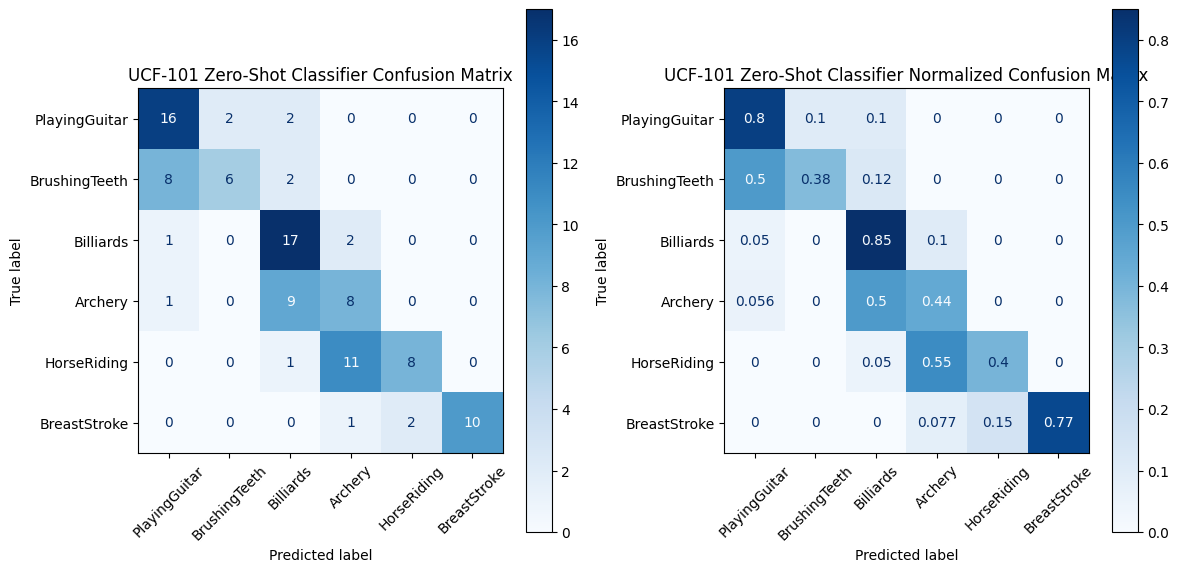

In [10]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ucf_class_names)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=ucf_class_names)
fig, ax = plt.subplots(1, 2, figsize=(12,6))
disp.plot(ax=ax[0], cmap='Blues', xticks_rotation=45)
disp_norm.plot(ax=ax[1], cmap='Blues', xticks_rotation=45)
ax[0].set_title('UCF-101 Zero-Shot Classifier Confusion Matrix')
ax[1].set_title('UCF-101 Zero-Shot Classifier Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
f'VideoMAE Zeroshot Accuracy on UCF-101 {accuracy:.2%}'

'VideoMAE Zeroshot Accuracy on UCF-101 60.75%'

We report an average $60\%$ accuracy for this subset of classses for zero-shot inference with Text-to-concept.